In [ ]:
import pandas as pd
df=pd.read_csv('large_sales_data.csv')

In [ ]:
print("number of rows and columns: ",df.shape)

number of rows and columns:  (5000, 13)


In [ ]:
df.head(5)

,order_id,customer_name,product,category,quantity,unit_price,revenue,order_date,city,region,sales_rep,payment_method,order_status
0,1001,Sneha Reddy,Monitor,Electronics,12,22000,264000,2023-05-21,Mumbai,West,Meera Patel,UPI,Delivered
1,1002,Ramesh Kumar,Printer,Electronics,10,12000,120000,2023-08-05,Delhi,North,Anil Sharma,Credit Card,Shipped
2,1003,Rahul Mishra,Mouse,Accessories,10,800,8000,2023-01-14,Ahmedabad,West,Meera Patel,Cash on Delivery,Shipped
3,1004,Suresh Rao,Tablet,Electronics,5,32000,160000,2023-01-04,Surat,West,Ravi Kumar,Cash on Delivery,Processing
4,1005,Priya Patel,Headphones,Electronics,4,3500,14000,2023-06-22,Bangalore,South,Sunita Rao,Cash on Delivery,Delivered


In [ ]:
df.columns

Index(['order_id', 'customer_name', 'product', 'category', 'quantity',
       'unit_price', 'revenue', 'order_date', 'city', 'region', 'sales_rep',
       'payment_method', 'order_status'],
      dtype='object')

In [ ]:
df.dtypes

,0
order_id,int64
customer_name,object
product,object
category,object
quantity,int64
unit_price,int64
revenue,int64
order_date,object
city,object
region,object


In [ ]:
df.isnull().sum()


,0
order_id,0
customer_name,0
product,0
category,0
quantity,0
unit_price,0
revenue,0
order_date,0
city,0
region,0


In [ ]:
df.duplicated().sum()

np.int64(0)

cleaning

In [ ]:
df=df.drop_duplicates()


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
#numerical columns
df['quantity']=df['quantity'].fillna(df['quantity'].mean())
df['unit_price']=df['unit_price'].fillna(df['unit_price'].mean())
df['revenue']=df['revenue'].fillna(df['revenue'].mean())

In [ ]:
#catogorical columns
df['category']=df['category'].fillna(df['category'].mode()[0])
df['city'] = df['city'].fillna(df['city'].mode()[0])
df['region'] = df['region'].fillna(df['region'].mode()[0])
df['payment_method'] = df['payment_method'].fillna(df['payment_method'].mode()[0])
df['order_status'] = df['order_status'].fillna(df['order_status'].mode()[0])

In [ ]:
#convert date column
df['order_date']=pd.to_datetime(df['order_date'])

In [ ]:
df.dtypes

,0
order_id,int64
customer_name,object
product,object
category,object
quantity,int64
unit_price,int64
revenue,int64
order_date,datetime64[ns]
city,object
region,object


In [ ]:
#rename column
df.rename(columns={
    'unit_price':'price_per_unit'
},inplace=True)

In [ ]:
df.to_csv('cleaned_sales_data.csv',index=False)

SQLite

In [ ]:
import sqlite3

In [ ]:
conn=sqlite3.connect('sales_project.db')

In [ ]:
df.to_sql('sales_project',conn,if_exists='replace',index=False)

5000

In [ ]:
#sql queries
#Orders with revenue greater than 10000
query1="""select * from sales_project where revenue> 10000"""
pd.read_sql(query1,conn)

,order_id,customer_name,product,category,quantity,price_per_unit,revenue,order_date,city,region,sales_rep,payment_method,order_status
0,1001,Sneha Reddy,Monitor,Electronics,12,22000,264000,2023-05-21 00:00:00,Mumbai,West,Meera Patel,UPI,Delivered
1,1002,Ramesh Kumar,Printer,Electronics,10,12000,120000,2023-08-05 00:00:00,Delhi,North,Anil Sharma,Credit Card,Shipped
2,1004,Suresh Rao,Tablet,Electronics,5,32000,160000,2023-01-04 00:00:00,Surat,West,Ravi Kumar,Cash on Delivery,Processing
3,1005,Priya Patel,Headphones,Electronics,4,3500,14000,2023-06-22 00:00:00,Bangalore,South,Sunita Rao,Cash on Delivery,Delivered
4,1006,Suresh Rao,Webcam,Accessories,10,2500,25000,2023-05-16 00:00:00,Kolkata,East,Anil Sharma,Cash on Delivery,Delivered
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3570,5995,Suresh Rao,Monitor,Electronics,2,22000,44000,2023-09-26 00:00:00,Mumbai,West,Sunita Rao,Cash on Delivery,Delivered
3571,5996,Ananya Das,Mouse,Accessories,13,800,10400,2023-11-18 00:00:00,Bangalore,South,Meera Patel,Net Banking,Cancelled
3572,5997,Suresh Rao,Webcam,Accessories,9,2500,22500,2023-06-07 00:00:00,Chennai,South,Sunita Rao,Credit Card,Delivered
3573,5999,Arjun Nair,Laptop,Electronics,14,45000,630000,2023-07-30 00:00:00,Delhi,North,Ravi Kumar,Cash on Delivery,Shipped


In [ ]:
#Highest revenue orders

query2="""select * from sales_project order by revenue desc limit 5"""
pd.read_sql(query2,conn)

,order_id,customer_name,product,category,quantity,price_per_unit,revenue,order_date,city,region,sales_rep,payment_method,order_status
0,1021,Tanvi Mehta,Laptop,Electronics,15,45000,675000,2023-07-05 00:00:00,Delhi,North,Deepak Joshi,UPI,Delivered
1,1456,Sneha Reddy,Laptop,Electronics,15,45000,675000,2023-11-11 00:00:00,Kolkata,East,Ravi Kumar,Net Banking,Shipped
2,1525,Arjun Nair,Laptop,Electronics,15,45000,675000,2023-11-24 00:00:00,Pune,West,Anil Sharma,Credit Card,Delivered
3,1572,Ananya Das,Laptop,Electronics,15,45000,675000,2023-06-15 00:00:00,Bangalore,South,Anil Sharma,Net Banking,Cancelled
4,1802,Ramesh Kumar,Laptop,Electronics,15,45000,675000,2023-12-12 00:00:00,Jaipur,North,Sunita Rao,Cash on Delivery,Delivered


In [ ]:
#Average revenue
query3="""select avg(revenue) as average_revenue from sales_project"""
pd.read_sql(query3,conn)

,average_revenue
0,99169.52


In [ ]:
#Revenue by category
quer4="""select category,sum(revenue) as total_revenue from sales_project
group by category"""
pd.read_sql(quer4,conn)

,category,total_revenue
0,Accessories,21515100
1,Electronics,474332500


In [ ]:
query5 = """
SELECT *,

CASE
WHEN revenue > 1000 THEN 'High Revenue'
ELSE 'Low Revenue'
END AS revenue_type

FROM sales_project
"""

pd.read_sql(query5, conn)

,order_id,customer_name,product,category,quantity,price_per_unit,revenue,order_date,city,region,sales_rep,payment_method,order_status,revenue_type
0,1001,Sneha Reddy,Monitor,Electronics,12,22000,264000,2023-05-21 00:00:00,Mumbai,West,Meera Patel,UPI,Delivered,High Revenue
1,1002,Ramesh Kumar,Printer,Electronics,10,12000,120000,2023-08-05 00:00:00,Delhi,North,Anil Sharma,Credit Card,Shipped,High Revenue
2,1003,Rahul Mishra,Mouse,Accessories,10,800,8000,2023-01-14 00:00:00,Ahmedabad,West,Meera Patel,Cash on Delivery,Shipped,High Revenue
3,1004,Suresh Rao,Tablet,Electronics,5,32000,160000,2023-01-04 00:00:00,Surat,West,Ravi Kumar,Cash on Delivery,Processing,High Revenue
4,1005,Priya Patel,Headphones,Electronics,4,3500,14000,2023-06-22 00:00:00,Bangalore,South,Sunita Rao,Cash on Delivery,Delivered,High Revenue
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,5996,Ananya Das,Mouse,Accessories,13,800,10400,2023-11-18 00:00:00,Bangalore,South,Meera Patel,Net Banking,Cancelled,High Revenue
4996,5997,Suresh Rao,Webcam,Accessories,9,2500,22500,2023-06-07 00:00:00,Chennai,South,Sunita Rao,Credit Card,Delivered,High Revenue
4997,5998,Arjun Nair,Webcam,Accessories,1,2500,2500,2023-04-07 00:00:00,Jaipur,North,Kavya Reddy,Net Banking,Cancelled,High Revenue
4998,5999,Arjun Nair,Laptop,Electronics,14,45000,630000,2023-07-30 00:00:00,Delhi,North,Ravi Kumar,Cash on Delivery,Shipped,High Revenue


In [ ]:
query = """
SELECT *,

CASE
WHEN revenue > 1000 THEN 'High'
ELSE 'Low'
END AS revenue_category,

CASE
WHEN quantity >= 5 THEN 'Bulk Order'
ELSE 'Small Order'
END AS order_size

FROM sales_project
"""

In [ ]:
transformed_df = pd.read_sql(query, conn)

transformed_df.to_csv(
    'transformed_sales_data.csv',
    index=False
)

ETL Pipeline

In [ ]:
#Extract
extract_df=pd.read_csv('large_sales_data.csv')

In [ ]:
#Transform
transform_df=extract_df.drop_duplicates()
transform_df=transform_df.fillna(0)

In [ ]:
#Load
transform_df.to_csv('etl_output.csv',index=False)

Visualization

In [ ]:
import matplotlib.pyplot as plt


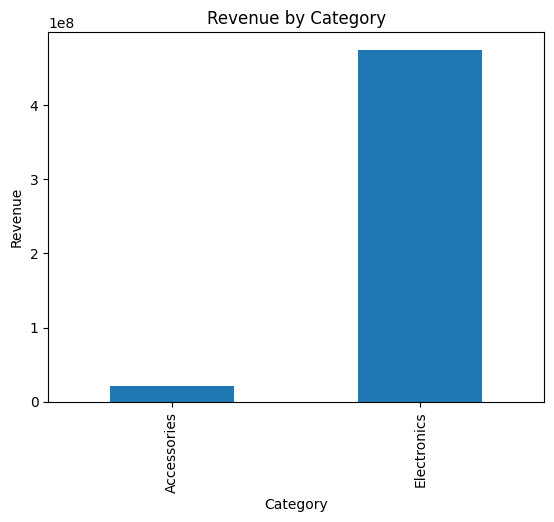

In [ ]:
#Bar Chart — Revenue by Category
category_revenue = df.groupby(
    'category'
)['revenue'].sum()

category_revenue.plot(kind='bar')

plt.title('Revenue by Category')

plt.xlabel('Category')

plt.ylabel('Revenue')

plt.show()

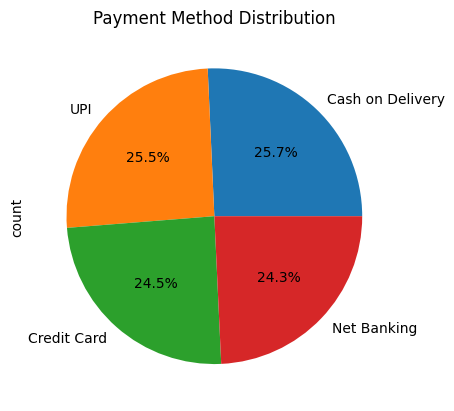

In [ ]:
#Pie Chart — Payment Method Distribution
df['payment_method'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Payment Method Distribution')

plt.show()

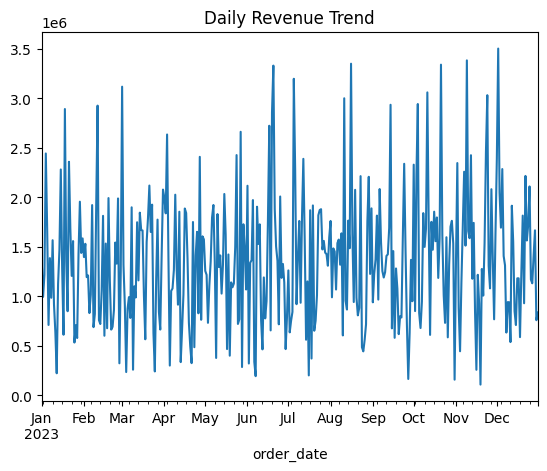

In [ ]:
#Line Chart — Revenue Trend
daily_revenue = df.groupby(
    'order_date'
)['revenue'].sum()

daily_revenue.plot(kind='line')

plt.title('Daily Revenue Trend')

plt.show()

Machine Learning Model

In [ ]:
X = df[['quantity', 'price_per_unit']]

y = df['revenue']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

model.fit(X_train, y_train)

RandomForestRegressor()

In [ ]:
predictions = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, predictions))

print("R2 Score:", r2_score(y_test, predictions))

MAE: 0.0
R2 Score: 1.0


Install PySpark

In [ ]:
!pip install pyspark

In [ ]:
from pyspark.sql import SparkSession

In [ ]:
spark = SparkSession.builder \
    .appName("CapstoneProject") \
    .getOrCreate()

In [ ]:
spark_df = spark.read.csv(
    'large_sales_data.csv',
    header=True,
    inferSchema=True
)

In [ ]:
spark_df.show(5)

+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|order_id|customer_name|   product|   category|quantity|unit_price|revenue|order_date|     city|region|  sales_rep|  payment_method|order_status|
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|    1001|  Sneha Reddy|   Monitor|Electronics|      12|     22000| 264000|2023-05-21|   Mumbai|  West|Meera Patel|             UPI|   Delivered|
|    1002| Ramesh Kumar|   Printer|Electronics|      10|     12000| 120000|2023-08-05|    Delhi| North|Anil Sharma|     Credit Card|     Shipped|
|    1003| Rahul Mishra|     Mouse|Accessories|      10|       800|   8000|2023-01-14|Ahmedabad|  West|Meera Patel|Cash on Delivery|     Shipped|
|    1004|   Suresh Rao|    Tablet|Electronics|       5|     32000| 160000|2023-01-04|    Surat|  West| Ravi Kumar|Cash on D

In [ ]:
spark_df.printSchema()

root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)



bronze layer

In [ ]:
spark_df.write.mode('overwrite').parquet(
    'bronze_layer'
)

In [ ]:
bronze_df = spark.read.parquet(
    'bronze_layer'
)

In [ ]:
bronze_df.show(5)

+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|order_id|customer_name|   product|   category|quantity|unit_price|revenue|order_date|     city|region|  sales_rep|  payment_method|order_status|
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|    1001|  Sneha Reddy|   Monitor|Electronics|      12|     22000| 264000|2023-05-21|   Mumbai|  West|Meera Patel|             UPI|   Delivered|
|    1002| Ramesh Kumar|   Printer|Electronics|      10|     12000| 120000|2023-08-05|    Delhi| North|Anil Sharma|     Credit Card|     Shipped|
|    1003| Rahul Mishra|     Mouse|Accessories|      10|       800|   8000|2023-01-14|Ahmedabad|  West|Meera Patel|Cash on Delivery|     Shipped|
|    1004|   Suresh Rao|    Tablet|Electronics|       5|     32000| 160000|2023-01-04|    Surat|  West| Ravi Kumar|Cash on D

silver layer

In [ ]:
silver_df = bronze_df.dropna()

In [ ]:
silver_df = silver_df.dropDuplicates()

In [ ]:
silver_df.write.mode('overwrite').parquet(
    'silver_layer'
)

In [ ]:
silver_read = spark.read.parquet(
    'silver_layer'
)

In [ ]:
silver_read.show(5)

+--------+-------------+--------+-----------+--------+----------+-------+----------+---------+------+-----------+--------------+------------+
|order_id|customer_name| product|   category|quantity|unit_price|revenue|order_date|     city|region|  sales_rep|payment_method|order_status|
+--------+-------------+--------+-----------+--------+----------+-------+----------+---------+------+-----------+--------------+------------+
|    1246|  Divya Singh|Keyboard|Accessories|      11|      1200|  13200|2023-02-07|  Kolkata|  East|Kavya Reddy|   Net Banking|     Shipped|
|    1323|   Ananya Das|  Webcam|Accessories|       7|      2500|  17500|2023-01-24|  Kolkata|  East|Meera Patel|           UPI|   Delivered|
|    1386|Kavya Nambiar| Speaker|Electronics|      13|      4500|  58500|2023-04-16|Bangalore| South|Meera Patel|   Credit Card|  Processing|
|    1939|   Amit Verma|Keyboard|Accessories|       8|      1200|   9600|2023-12-21|  Kolkata|  East| Priya Nair|           UPI|   Delivered|
|    2

gold layer

In [ ]:
gold_df = silver_df.groupBy(
    'category'
).sum('revenue')

In [ ]:
gold_df = gold_df.withColumnRenamed(
    'sum(revenue)',
    'total_revenue'
)

In [ ]:
gold_df.show()

+-----------+-------------+
|   category|total_revenue|
+-----------+-------------+
|Electronics|    474332500|
|Accessories|     21515100|
+-----------+-------------+



In [ ]:
gold_df.write.mode('overwrite').parquet(
    'gold_layer'
)

In [ ]:
parquet_df = spark.read.parquet(
    'gold_layer'
)

In [ ]:
parquet_df.show()

+-----------+-------------+
|   category|total_revenue|
+-----------+-------------+
|Electronics|    474332500|
|Accessories|     21515100|
+-----------+-------------+



In [ ]:
pandas_df = parquet_df.toPandas()

In [ ]:
pandas_df.head()

,category,total_revenue
0,Electronics,474332500
1,Accessories,21515100


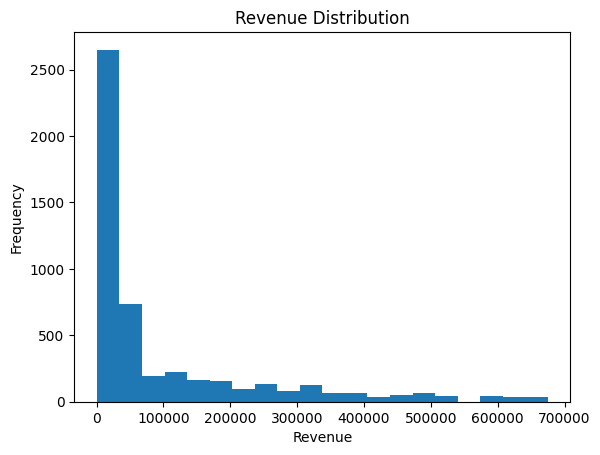

In [ ]:
import matplotlib.pyplot as plt

df['revenue'].plot(
    kind='hist',
    bins=20
)

plt.title('Revenue Distribution')

plt.xlabel('Revenue')

plt.show()

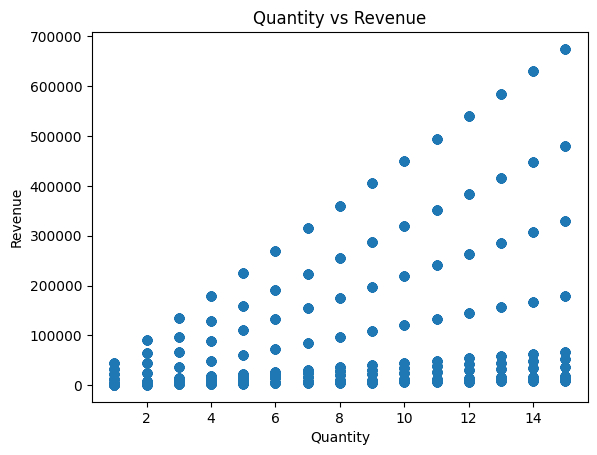

In [ ]:
plt.scatter(
    df['quantity'],
    df['revenue']
)

plt.xlabel('Quantity')

plt.ylabel('Revenue')

plt.title('Quantity vs Revenue')

plt.show()

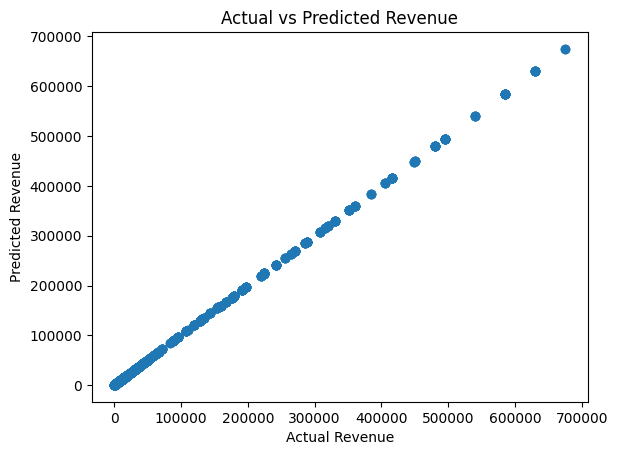

In [ ]:
plt.scatter(
    y_test,
    predictions
)

plt.xlabel("Actual Revenue")

plt.ylabel("Predicted Revenue")

plt.title("Actual vs Predicted Revenue")

plt.show()